## 1. Environment Setup & GPU Check

In [44]:
# import sys
# !{sys.executable} -m pip install --upgrade pip
# !{sys.executable} -m pip install torch


In [45]:
import torch

## 2. Install Dependencies


In [46]:
# !pip install monai[all] tensorboard pillow scikit-learn matplotlib tqdm

## 3. Configuration Constants (Paper Hyperparameters)


In [47]:
from pathlib import Path
import random
import numpy as np
import torch


DATA_DIR = Path("dataset/331")

CLASS_NAMES = ["Normal_with_labels", "DDH_with_labels"]

IMAGE_SIZE = 224  
N_CHANNELS = 3    # Convert grayscale to RGB for ImageNet pretrained models

BATCH_SIZE = 32
EPOCHS = 50
LEARNING_RATE = 1e-4  # 0.0001

TEST_SPLIT = 0.20

RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

print(f"Configuration loaded:")
print(f"  - Data Directory: {DATA_DIR.absolute()}")
print(f"  - Image Size: {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"  - Batch Size: {BATCH_SIZE}")
print(f"  - Epochs: {EPOCHS}")
print(f"  - Learning Rate: {LEARNING_RATE}")
print(f"  - Train/Test Split: {int((1-TEST_SPLIT)*100)}/{int(TEST_SPLIT*100)}")
print(f"  - Random Seed: {RANDOM_SEED}")

Configuration loaded:
  - Data Directory: /Users/anagnole/Projects/ThesisProject/notebooks/dataset/331
  - Image Size: 224x224
  - Batch Size: 32
  - Epochs: 50
  - Learning Rate: 0.0001
  - Train/Test Split: 80/20
  - Random Seed: 42


## 4. Load Dataset (Images with Labels - Overfitting Test)

Loading from `Normal_with_labels` and `DDH_with_labels` folders to replicate the paper's suspected artifact-based classification.

In [48]:
image_files = []
image_labels = []

for class_idx, class_name in enumerate(CLASS_NAMES):
    class_dir = DATA_DIR / class_name
    
    files = [str(p) for p in class_dir.iterdir() if p.is_file() and p.suffix.lower() == '.jpg']
    image_files.extend(files)
    image_labels.extend([class_idx] * len(files))
    print(f"  {class_name}: {len(files)} images (label={class_idx})")

print(f"\nTotal images loaded: {len(image_files)}")
print(f"  - Normal (class 0): {image_labels.count(0)}")
print(f"  - DDH (class 1): {image_labels.count(1)}")
print(f"\nPaper reference: 354 subjects (234 Normal, 120 DDH)")

  Normal_with_labels: 236 images (label=0)
  DDH_with_labels: 119 images (label=1)

Total images loaded: 355
  - Normal (class 0): 236
  - DDH (class 1): 119

Paper reference: 354 subjects (234 Normal, 120 DDH)


## 5. Train/Test Split (80/20 as per paper)

Using stratified split with fixed random seed for reproducibility.

In [49]:
from sklearn.model_selection import train_test_split

train_files, test_files, train_labels, test_labels = train_test_split(
    image_files,
    image_labels,
    test_size=TEST_SPLIT,
    random_state=RANDOM_SEED,
    stratify=image_labels
)

train_data = [{"img": f, "label": l} for f, l in zip(train_files, train_labels)]
test_data = [{"img": f, "label": l} for f, l in zip(test_files, test_labels)]

print(f"Data Split (80/20):")
print(f"  Training set: {len(train_data)} images")
print(f"    - Normal: {train_labels.count(0)}, DDH: {train_labels.count(1)}")
print(f"  Test set: {len(test_data)} images")
print(f"    - Normal: {test_labels.count(0)}, DDH: {test_labels.count(1)}")

Data Split (80/20):
  Training set: 284 images
    - Normal: 189, DDH: 95
  Test set: 71 images
    - Normal: 47, DDH: 24


## 6. Data Transforms (Paper Specifications)

### Preprocessing:
- Resize to 224×224 pixels
- Convert grayscale to 3-channel RGB (repeat channel)
- Normalize using ImageNet mean/std

### Augmentation (Training Only):
- Random Rotation (±10 degrees)
- Random Horizontal Flip
- Random Zoom

In [50]:
from monai.transforms import (
    Compose, LoadImageD, EnsureChannelFirstD, ResizeD,
    ScaleIntensityD, NormalizeIntensityD, RandFlipD, 
    RandRotateD, RandZoomD, RepeatChannelD,
    EnsureTypeD, Transform
)
import numpy as np
import torch
from PIL import Image
from torchvision import transforms as T

class LoadAndPreprocessD(Transform):
    
    def __init__(self, keys, image_size=224, imagenet_mean=None, imagenet_std=None):
        self.keys = keys if isinstance(keys, (list, tuple)) else [keys]
        self.image_size = image_size
        self.imagenet_mean = imagenet_mean or [0.485, 0.456, 0.406]
        self.imagenet_std = imagenet_std or [0.229, 0.224, 0.225]
        
        self.transform = T.Compose([
            T.Resize((image_size, image_size)),
            T.Grayscale(num_output_channels=3),  # Convert to 3-channel grayscale
            T.ToTensor(),
            T.Normalize(mean=self.imagenet_mean, std=self.imagenet_std)
        ])
    
    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            img = Image.open(d[key])
            
            if img.mode == 'RGBA':
                img = img.convert('RGB')
            elif img.mode == 'L':
                img = img.convert('RGB')
            elif img.mode != 'RGB':
                img = img.convert('RGB')
            
            d[key] = self.transform(img)
        
        return d


class AugmentD(Transform):
    
    def __init__(self, keys, rotation_degrees=10, zoom_range=(0.9, 1.1), flip_prob=0.5):
        self.keys = keys if isinstance(keys, (list, tuple)) else [keys]
        self.rotation_degrees = rotation_degrees
        self.zoom_range = zoom_range
        self.flip_prob = flip_prob
    
    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            img = d[key]
            
            # Random horizontal flip
            if torch.rand(1).item() < self.flip_prob:
                img = torch.flip(img, dims=[2]) 
            
            # Random rotation
            if torch.rand(1).item() < 0.5:
                angle = (torch.rand(1).item() * 2 - 1) * self.rotation_degrees
                img = T.functional.rotate(img, angle)
            
            # Random zoom
            if torch.rand(1).item() < 0.5:
                zoom = self.zoom_range[0] + torch.rand(1).item() * (self.zoom_range[1] - self.zoom_range[0])
                _, h, w = img.shape
                new_h, new_w = int(h / zoom), int(w / zoom)
                top = (h - new_h) // 2
                left = (w - new_w) // 2
                img = img[:, top:top+new_h, left:left+new_w]
                img = torch.nn.functional.interpolate(img.unsqueeze(0), size=(h, w), mode='bilinear', align_corners=False).squeeze(0)
            
            d[key] = img
        
        return d


train_transforms = Compose([
    LoadAndPreprocessD(
        keys="img", 
        image_size=IMAGE_SIZE,
        imagenet_mean=IMAGENET_MEAN,
        imagenet_std=IMAGENET_STD
    ),
    AugmentD(keys="img", rotation_degrees=10, zoom_range=(0.9, 1.1), flip_prob=0.5),
    EnsureTypeD(keys=["img", "label"]),
])

test_transforms = Compose([
    LoadAndPreprocessD(
        keys="img", 
        image_size=IMAGE_SIZE,
        imagenet_mean=IMAGENET_MEAN,
        imagenet_std=IMAGENET_STD
    ),
    EnsureTypeD(keys=["img", "label"]),
])

print("Transforms configured:")
print("  - Input: X-ray images (any format)")
print("  - Output: 3-channel 224x224 normalized tensors")
print("  - Augmentation (train): Rotation ±10°, Horizontal Flip, Zoom 0.9-1.1")

Transforms configured:
  - Input: X-ray images (any format)
  - Output: 3-channel 224x224 normalized tensors
  - Augmentation (train): Rotation ±10°, Horizontal Flip, Zoom 0.9-1.1


## 7. Create DataLoaders

In [51]:
from monai.data import Dataset, DataLoader

train_dataset = Dataset(data=train_data, transform=train_transforms)
test_dataset = Dataset(data=test_data, transform=test_transforms)


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=True if torch.cuda.is_available() else False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True if torch.cuda.is_available() else False
)

print(f"DataLoaders created:")
print(f"  Train: {len(train_loader)} batches (batch_size={BATCH_SIZE})")
print(f"  Test: {len(test_loader)} batches")


DataLoaders created:
  Train: 9 batches (batch_size=32)
  Test: 3 batches


## 8. Model Architecture (ResNet50 - ImageNet Pretrained)

As specified in Fraiwan et al. (2022):
- ResNet50 backbone with ImageNet pretrained weights
- Modified final layer for binary classification (1 output node)
- BCEWithLogitsLoss for training

In [52]:
import torch.nn as nn
from torchvision.models import resnet50, ResNet50_Weights

device = torch.device("mps")

model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 1) 

model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nModel: ResNet50 (ImageNet pretrained)")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Output: 1 node (binary classification)")


Model: ResNet50 (ImageNet pretrained)
  Total parameters: 23,510,081
  Trainable parameters: 23,510,081
  Output: 1 node (binary classification)


## 9. Loss Function & Optimizer (Paper Specifications)

- **Loss:** BCEWithLogitsLoss with class weighting for imbalance
- **Optimizer:** Adam with lr=1e-4

In [53]:
n_normal = train_labels.count(0)
n_ddh = train_labels.count(1)
pos_weight = torch.tensor([n_normal / n_ddh]).to(device)

print(f"Class distribution in training set:")
print(f"  Normal: {n_normal}")
print(f"  DDH: {n_ddh}")
print(f"  Positive weight: {pos_weight.item():.4f}")

loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(f"\nOptimizer: Adam (lr={LEARNING_RATE})")
print(f"Loss: BCEWithLogitsLoss (weighted)")

Class distribution in training set:
  Normal: 189
  DDH: 95
  Positive weight: 1.9895

Optimizer: Adam (lr=0.0001)
Loss: BCEWithLogitsLoss (weighted)


## 10. TensorBoard Setup

In [54]:
import os
os.environ["TENSORBOARD_BINARY"] = "/Users/anagnole/Projects/ThesisProject/.venv/bin/tensorboard"

%reload_ext tensorboard
from torch.utils.tensorboard import SummaryWriter
from pathlib import Path
from datetime import datetime

LOG_ROOT = Path("logs")
LOG_ROOT.mkdir(exist_ok=True)

run_name = f"fraiwan_replication_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
writer = SummaryWriter(str(LOG_ROOT / run_name))

print(f"TensorBoard logs: {LOG_ROOT / run_name}")

%tensorboard --logdir logs

TensorBoard logs: logs/fraiwan_replication_20260218_115003


Reusing TensorBoard on port 6007 (pid 55948), started 10:41:45 ago. (Use '!kill 55948' to kill it.)

## 11. Training Loop

Training for 50 epochs as specified in the paper.

In [55]:
from tqdm import tqdm
import numpy as np
from sklearn.metrics import roc_auc_score

def train_epoch(model, train_loader, loss_fn, optimizer, device):
    model.train()
    running_loss = 0.0
    
    for batch in train_loader:
        images = batch["img"].to(device)
        labels = batch["label"].float().unsqueeze(1).to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
    
    epoch_loss = running_loss / len(train_loader.dataset)
    return epoch_loss


def evaluate(model, data_loader, device):
    model.eval()
    all_probs = []
    all_labels = []
    
    with torch.no_grad():
        for batch in data_loader:
            images = batch["img"].to(device)
            labels = batch["label"].float().to(device)
            
            outputs = model(images)
            probs = torch.sigmoid(outputs).squeeze()
            
            all_probs.append(probs.cpu())
            all_labels.append(labels.cpu())
    
    all_probs = torch.cat(all_probs).numpy()
    all_labels = torch.cat(all_labels).numpy().astype(int)
    
    return all_probs, all_labels


print(f"Starting training for {EPOCHS} epochs...")

best_auc = 0.0
history = {"train_loss": [], "test_auc": []}

for epoch in range(EPOCHS):
    train_loss = train_epoch(model, train_loader, loss_fn, optimizer, device)
    
    test_probs, test_labels = evaluate(model, test_loader, device)
    test_auc = roc_auc_score(test_labels, test_probs)
    
    history["train_loss"].append(train_loss)
    history["test_auc"].append(test_auc)
    
    writer.add_scalar("Loss/train", train_loss, epoch)
    writer.add_scalar("AUC/test", test_auc, epoch)
    writer.flush()
    
    if test_auc > best_auc:
        best_auc = test_auc
        torch.save(model.state_dict(), "best_model.pth")
    
    print(f"Epoch {epoch+1:3d}/{EPOCHS} | Loss: {train_loss:.4f} | Test AUC: {test_auc:.4f}")

print(f"Training complete! Best Test AUC: {best_auc:.4f}")

Starting training for 50 epochs...
Epoch   1/50 | Loss: 0.8834 | Test AUC: 0.7606
Epoch   2/50 | Loss: 0.6955 | Test AUC: 0.8537
Epoch   3/50 | Loss: 0.4924 | Test AUC: 0.8537
Epoch   4/50 | Loss: 0.4614 | Test AUC: 0.9326
Epoch   5/50 | Loss: 0.4676 | Test AUC: 0.9273
Epoch   6/50 | Loss: 0.4173 | Test AUC: 0.9300
Epoch   7/50 | Loss: 0.3531 | Test AUC: 0.9637
Epoch   8/50 | Loss: 0.3660 | Test AUC: 0.9574
Epoch   9/50 | Loss: 0.3184 | Test AUC: 0.9362
Epoch  10/50 | Loss: 0.3083 | Test AUC: 0.9246
Epoch  11/50 | Loss: 0.3433 | Test AUC: 0.9583
Epoch  12/50 | Loss: 0.3129 | Test AUC: 0.9450
Epoch  13/50 | Loss: 0.2586 | Test AUC: 0.9672
Epoch  14/50 | Loss: 0.3352 | Test AUC: 0.9832
Epoch  15/50 | Loss: 0.2644 | Test AUC: 0.9690
Epoch  16/50 | Loss: 0.2660 | Test AUC: 0.9690
Epoch  17/50 | Loss: 0.2467 | Test AUC: 0.9681
Epoch  18/50 | Loss: 0.2597 | Test AUC: 0.9752
Epoch  19/50 | Loss: 0.2337 | Test AUC: 0.9752
Epoch  20/50 | Loss: 0.3214 | Test AUC: 0.9592
Epoch  21/50 | Loss: 0.25

## 12. Final Evaluation - All Paper Metrics

Computing all metrics reported in Fraiwan et al. (2022):
- Accuracy
- Sensitivity (Recall)
- Specificity
- Precision
- F1-Score
- AUC-ROC

In [56]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)
import matplotlib.pyplot as plt

model.load_state_dict(torch.load("best_model.pth", map_location=device))

test_probs, test_labels = evaluate(model, test_loader, device)
test_preds = (test_probs >= 0.5).astype(int)

tn, fp, fn, tp = confusion_matrix(test_labels, test_preds).ravel()

accuracy = accuracy_score(test_labels, test_preds)
sensitivity = recall_score(test_labels, test_preds)  # Recall = Sensitivity
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
precision = precision_score(test_labels, test_preds)
f1 = f1_score(test_labels, test_preds)
auc_roc = roc_auc_score(test_labels, test_probs)

print("FINAL TEST RESULTS - Fraiwan et al. (2022) Replication")
print(f"\nDataset: Images WITH measurement labels (overfitting test)")
print(f"Model: ResNet50 (ImageNet pretrained)")
print(f"\nConfusion Matrix:")
print(f"                 Predicted")
print(f"                 Normal  DDH")
print(f"  Actual Normal    {tn:3d}   {fp:3d}")
print(f"  Actual DDH       {fn:3d}   {tp:3d}")
print(f"\n" + "-" * 40)
print(f"METRICS (Paper Format):")
print("-" * 40)
print(f"  Accuracy:              {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  Sensitivity (Recall):  {sensitivity:.4f} ({sensitivity*100:.2f}%)")
print(f"  Specificity:           {specificity:.4f} ({specificity*100:.2f}%)")
print(f"  Precision:             {precision:.4f} ({precision*100:.2f}%)")
print(f"  F1-Score:              {f1:.4f} ({f1*100:.2f}%)")
print(f"  AUC-ROC:               {auc_roc:.4f} ({auc_roc*100:.2f}%)")


FINAL TEST RESULTS - Fraiwan et al. (2022) Replication

Dataset: Images WITH measurement labels (overfitting test)
Model: ResNet50 (ImageNet pretrained)

Confusion Matrix:
                 Predicted
                 Normal  DDH
  Actual Normal     46     1
  Actual DDH         2    22

----------------------------------------
METRICS (Paper Format):
----------------------------------------
  Accuracy:              0.9577 (95.77%)
  Sensitivity (Recall):  0.9167 (91.67%)
  Specificity:           0.9787 (97.87%)
  Precision:             0.9565 (95.65%)
  F1-Score:              0.9362 (93.62%)
  AUC-ROC:               0.9832 (98.32%)


## 13. ROC Curve Visualization

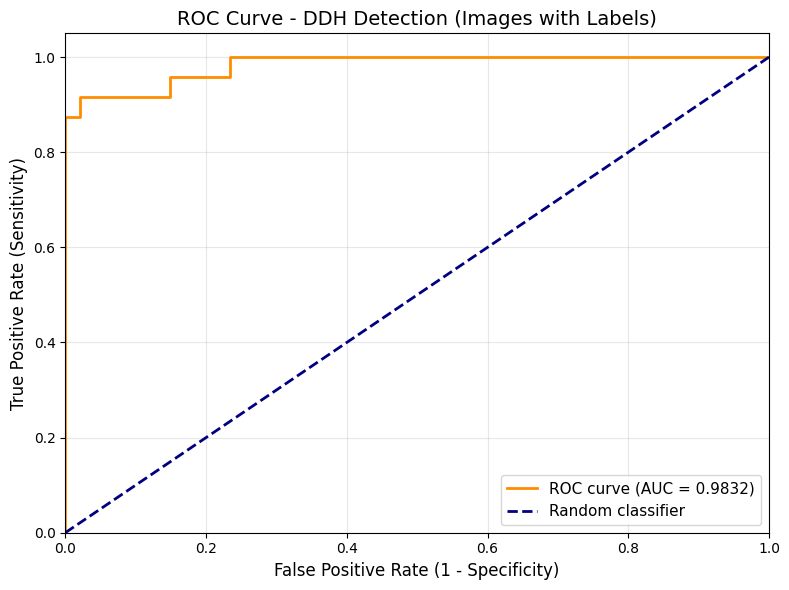

ROC curve saved to: roc_curve_with_labels.png


In [57]:
# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(test_labels, test_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_roc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('ROC Curve - DDH Detection (Images with Labels)', fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve_with_labels.png', dpi=150)
plt.show()

print("ROC curve saved to: roc_curve_with_labels.png")

## 14. Training History Visualization

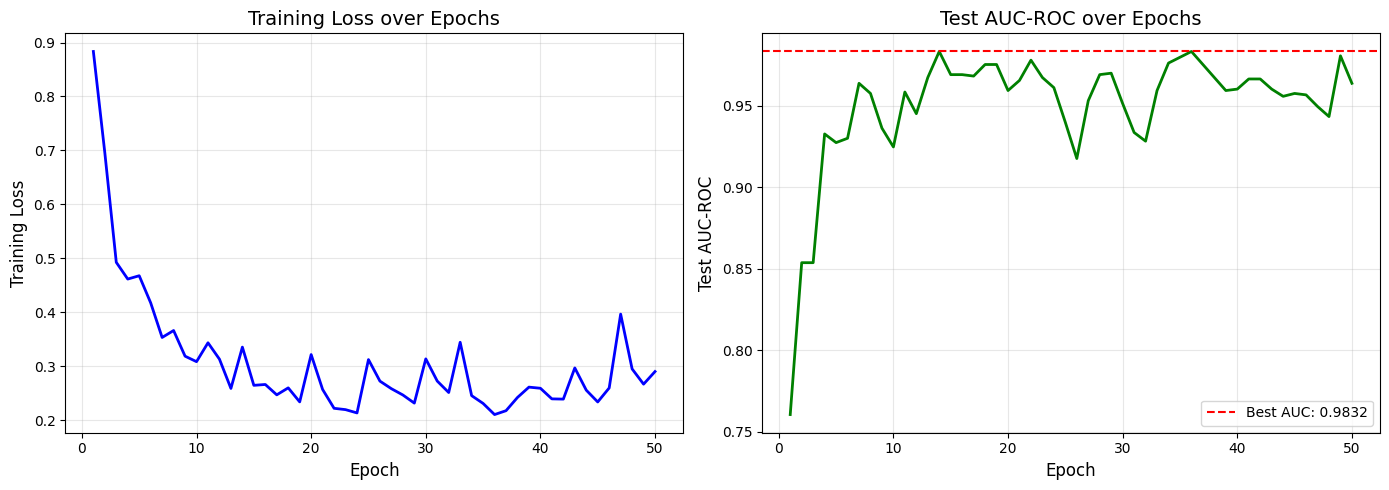

Training history saved to: training_history.png


In [58]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, EPOCHS+1), history["train_loss"], 'b-', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Training Loss', fontsize=12)
axes[0].set_title('Training Loss over Epochs', fontsize=14)
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, EPOCHS+1), history["test_auc"], 'g-', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Test AUC-ROC', fontsize=12)
axes[1].set_title('Test AUC-ROC over Epochs', fontsize=14)
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=best_auc, color='r', linestyle='--', label=f'Best AUC: {best_auc:.4f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('training_history.png', dpi=150)
plt.show()

print("Training history saved to: training_history.png")

## 15. Cleanup

In [59]:
writer.close()
print("TensorBoard writer closed.")
print("EXPERIMENT 1 COMPLETE - Images WITH Labels")
print(f"\nResults support the overfitting hypothesis:")
print(f"  - Accuracy: {accuracy*100:.2f}%")
print(f"  - AUC-ROC: {auc_roc*100:.2f}%")
print(f"\nNow running Experiment 2 with CLEAN images for comparison...")

TensorBoard writer closed.
EXPERIMENT 1 COMPLETE - Images WITH Labels

Results support the overfitting hypothesis:
  - Accuracy: 95.77%
  - AUC-ROC: 98.32%

Now running Experiment 2 with CLEAN images for comparison...


---

# EXPERIMENT 2: Clean Images (Without Labels)

Now we repeat the exact same methodology on images **WITHOUT** measurement labels to test the overfitting hypothesis.


In [60]:
exp1_results = {
    "accuracy": accuracy,
    "sensitivity": sensitivity,
    "specificity": specificity,
    "precision": precision,
    "f1": f1,
    "auc_roc": auc_roc,
    "confusion_matrix": (tn, fp, fn, tp)
}

CLASS_NAMES_CLEAN = ["Normal", "DDH"]

image_files_clean = []
image_labels_clean = []

for class_idx, class_name in enumerate(CLASS_NAMES_CLEAN):
    class_dir = DATA_DIR / class_name
    
    files = [str(p) for p in class_dir.iterdir() if p.is_file() and p.suffix.lower() == '.jpg']
    image_files_clean.extend(files)
    image_labels_clean.extend([class_idx] * len(files))
    print(f"  {class_name}: {len(files)} images (label={class_idx})")

print(f"\nTotal CLEAN images loaded: {len(image_files_clean)}")
print(f"  - Normal (class 0): {image_labels_clean.count(0)}")
print(f"  - DDH (class 1): {image_labels_clean.count(1)}")

  Normal: 232 images (label=0)
  DDH: 119 images (label=1)

Total CLEAN images loaded: 351
  - Normal (class 0): 232
  - DDH (class 1): 119


In [61]:
train_files_clean, test_files_clean, train_labels_clean, test_labels_clean = train_test_split(
    image_files_clean,
    image_labels_clean,
    test_size=TEST_SPLIT,
    random_state=RANDOM_SEED,
    stratify=image_labels_clean
)

train_data_clean = [{"img": f, "label": l} for f, l in zip(train_files_clean, train_labels_clean)]
test_data_clean = [{"img": f, "label": l} for f, l in zip(test_files_clean, test_labels_clean)]

print(f"Clean Data Split (80/20):")
print(f"  Training set: {len(train_data_clean)} images")
print(f"    - Normal: {train_labels_clean.count(0)}, DDH: {train_labels_clean.count(1)}")
print(f"  Test set: {len(test_data_clean)} images")
print(f"    - Normal: {test_labels_clean.count(0)}, DDH: {test_labels_clean.count(1)}")

Clean Data Split (80/20):
  Training set: 280 images
    - Normal: 185, DDH: 95
  Test set: 71 images
    - Normal: 47, DDH: 24


In [62]:
train_dataset_clean = Dataset(data=train_data_clean, transform=train_transforms)
test_dataset_clean = Dataset(data=test_data_clean, transform=test_transforms)

train_loader_clean = DataLoader(
    train_dataset_clean,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=True if torch.cuda.is_available() else False
)

test_loader_clean = DataLoader(
    test_dataset_clean,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True if torch.cuda.is_available() else False
)

print(f"Clean DataLoaders created:")
print(f"  Train: {len(train_loader_clean)} batches")
print(f"  Test: {len(test_loader_clean)} batches")

Clean DataLoaders created:
  Train: 9 batches
  Test: 3 batches


In [63]:
model_clean = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
model_clean.fc = nn.Linear(model_clean.fc.in_features, 1)
model_clean = model_clean.to(device)

n_normal_clean = train_labels_clean.count(0)
n_ddh_clean = train_labels_clean.count(1)
pos_weight_clean = torch.tensor([n_normal_clean / n_ddh_clean]).to(device)

loss_fn_clean = nn.BCEWithLogitsLoss(pos_weight=pos_weight_clean)
optimizer_clean = torch.optim.Adam(model_clean.parameters(), lr=LEARNING_RATE)

print(f"Model 2 (Clean) initialized:")
print(f"  Class weights - Normal: {n_normal_clean}, DDH: {n_ddh_clean}")
print(f"  Positive weight: {pos_weight_clean.item():.4f}")

Model 2 (Clean) initialized:
  Class weights - Normal: 185, DDH: 95
  Positive weight: 1.9474


In [64]:
run_name_clean = f"fraiwan_CLEAN_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
writer_clean = SummaryWriter(str(LOG_ROOT / run_name_clean))

print(f"Starting training on CLEAN images for {EPOCHS} epochs...")

best_auc_clean = 0.0
history_clean = {"train_loss": [], "test_auc": []}

for epoch in range(EPOCHS):
    train_loss = train_epoch(model_clean, train_loader_clean, loss_fn_clean, optimizer_clean, device)
    
    test_probs_clean, test_labels_clean_eval = evaluate(model_clean, test_loader_clean, device)
    test_auc = roc_auc_score(test_labels_clean_eval, test_probs_clean)
    
    history_clean["train_loss"].append(train_loss)
    history_clean["test_auc"].append(test_auc)
    
    writer_clean.add_scalar("Loss/train", train_loss, epoch)
    writer_clean.add_scalar("AUC/test", test_auc, epoch)
    writer_clean.flush()
    
    if test_auc > best_auc_clean:
        best_auc_clean = test_auc
        torch.save(model_clean.state_dict(), "best_model_clean.pth")
    
    print(f"Epoch {epoch+1:3d}/{EPOCHS} | Loss: {train_loss:.4f} | Test AUC: {test_auc:.4f}")

print(f"Best Test AUC (Clean): {best_auc_clean:.4f}")

Starting training on CLEAN images for 50 epochs...
Epoch   1/50 | Loss: 0.8500 | Test AUC: 0.7270
Epoch   2/50 | Loss: 0.6887 | Test AUC: 0.8395
Epoch   3/50 | Loss: 0.5780 | Test AUC: 0.8998
Epoch   4/50 | Loss: 0.5080 | Test AUC: 0.9300
Epoch   5/50 | Loss: 0.4478 | Test AUC: 0.9309
Epoch   6/50 | Loss: 0.4296 | Test AUC: 0.9637
Epoch   7/50 | Loss: 0.3428 | Test AUC: 0.9424
Epoch   8/50 | Loss: 0.3485 | Test AUC: 0.9592
Epoch   9/50 | Loss: 0.3510 | Test AUC: 0.9078
Epoch  10/50 | Loss: 0.3146 | Test AUC: 0.9557
Epoch  11/50 | Loss: 0.3508 | Test AUC: 0.9362
Epoch  12/50 | Loss: 0.3451 | Test AUC: 0.9601
Epoch  13/50 | Loss: 0.2574 | Test AUC: 0.9397
Epoch  14/50 | Loss: 0.2220 | Test AUC: 0.9450
Epoch  15/50 | Loss: 0.2848 | Test AUC: 0.9592
Epoch  16/50 | Loss: 0.3017 | Test AUC: 0.9353
Epoch  17/50 | Loss: 0.2957 | Test AUC: 0.9335
Epoch  18/50 | Loss: 0.2140 | Test AUC: 0.9291
Epoch  19/50 | Loss: 0.2457 | Test AUC: 0.9397
Epoch  20/50 | Loss: 0.2604 | Test AUC: 0.9468
Epoch  21

In [65]:
model_clean.load_state_dict(torch.load("best_model_clean.pth", map_location=device))

test_probs_clean, test_labels_clean_eval = evaluate(model_clean, test_loader_clean, device)
test_preds_clean = (test_probs_clean >= 0.5).astype(int)

tn_c, fp_c, fn_c, tp_c = confusion_matrix(test_labels_clean_eval, test_preds_clean).ravel()

accuracy_clean = accuracy_score(test_labels_clean_eval, test_preds_clean)
sensitivity_clean = recall_score(test_labels_clean_eval, test_preds_clean)
specificity_clean = tn_c / (tn_c + fp_c) if (tn_c + fp_c) > 0 else 0
precision_clean = precision_score(test_labels_clean_eval, test_preds_clean)
f1_clean = f1_score(test_labels_clean_eval, test_preds_clean)
auc_roc_clean = roc_auc_score(test_labels_clean_eval, test_probs_clean)

exp2_results = {
    "accuracy": accuracy_clean,
    "sensitivity": sensitivity_clean,
    "specificity": specificity_clean,
    "precision": precision_clean,
    "f1": f1_clean,
    "auc_roc": auc_roc_clean,
    "confusion_matrix": (tn_c, fp_c, fn_c, tp_c)
}

print("EXPERIMENT 2 RESULTS - CLEAN Images (No Labels)")
print(f"\nDataset: Images WITHOUT measurement labels")
print(f"Model: ResNet50 (ImageNet pretrained)")
print(f"\nConfusion Matrix:")
print(f"                 Predicted")
print(f"                 Normal  DDH")
print(f"  Actual Normal    {tn_c:3d}   {fp_c:3d}")
print(f"  Actual DDH       {fn_c:3d}   {tp_c:3d}")
print(f"\n" + "-" * 40)
print(f"METRICS:")
print("-" * 40)
print(f"  Accuracy:              {accuracy_clean:.4f} ({accuracy_clean*100:.2f}%)")
print(f"  Sensitivity (Recall):  {sensitivity_clean:.4f} ({sensitivity_clean*100:.2f}%)")
print(f"  Specificity:           {specificity_clean:.4f} ({specificity_clean*100:.2f}%)")
print(f"  Precision:             {precision_clean:.4f} ({precision_clean*100:.2f}%)")
print(f"  F1-Score:              {f1_clean:.4f} ({f1_clean*100:.2f}%)")
print(f"  AUC-ROC:               {auc_roc_clean:.4f} ({auc_roc_clean*100:.2f}%)")


EXPERIMENT 2 RESULTS - CLEAN Images (No Labels)

Dataset: Images WITHOUT measurement labels
Model: ResNet50 (ImageNet pretrained)

Confusion Matrix:
                 Predicted
                 Normal  DDH
  Actual Normal     44     3
  Actual DDH         3    21

----------------------------------------
METRICS:
----------------------------------------
  Accuracy:              0.9155 (91.55%)
  Sensitivity (Recall):  0.8750 (87.50%)
  Specificity:           0.9362 (93.62%)
  Precision:             0.8750 (87.50%)
  F1-Score:              0.8750 (87.50%)
  AUC-ROC:               0.9707 (97.07%)


## Comparison: With Labels vs. Clean Images

This is the critical comparison for the thesis hypothesis.

In [66]:
import pandas as pd

comparison_data = {
    "Metric": ["Accuracy", "Sensitivity", "Specificity", "Precision", "F1-Score", "AUC-ROC"],
    "With Labels (%)": [
        f"{exp1_results['accuracy']*100:.2f}",
        f"{exp1_results['sensitivity']*100:.2f}",
        f"{exp1_results['specificity']*100:.2f}",
        f"{exp1_results['precision']*100:.2f}",
        f"{exp1_results['f1']*100:.2f}",
        f"{exp1_results['auc_roc']*100:.2f}"
    ],
    "Clean Images (%)": [
        f"{exp2_results['accuracy']*100:.2f}",
        f"{exp2_results['sensitivity']*100:.2f}",
        f"{exp2_results['specificity']*100:.2f}",
        f"{exp2_results['precision']*100:.2f}",
        f"{exp2_results['f1']*100:.2f}",
        f"{exp2_results['auc_roc']*100:.2f}"
    ],
    "Difference (%)": [
        f"{(exp1_results['accuracy'] - exp2_results['accuracy'])*100:+.2f}",
        f"{(exp1_results['sensitivity'] - exp2_results['sensitivity'])*100:+.2f}",
        f"{(exp1_results['specificity'] - exp2_results['specificity'])*100:+.2f}",
        f"{(exp1_results['precision'] - exp2_results['precision'])*100:+.2f}",
        f"{(exp1_results['f1'] - exp2_results['f1'])*100:+.2f}",
        f"{(exp1_results['auc_roc'] - exp2_results['auc_roc'])*100:+.2f}"
    ]
}

comparison_df = pd.DataFrame(comparison_data)

print("COMPARISON: Images WITH Labels vs. CLEAN Images")
print()
print(comparison_df.to_string(index=False))
print()

auc_diff = (exp1_results['auc_roc'] - exp2_results['auc_roc']) * 100
acc_diff = (exp1_results['accuracy'] - exp2_results['accuracy']) * 100

if auc_diff > 5:
    print(f"AUC dropped by {auc_diff:.1f}% when using clean images.")
    print(f"This SUPPORTS the hypothesis that the model was")
    print(f"overfitting to measurement labels/artifacts.")
    print(f"The original paper's results may be INVALID due to")
    print(f"data leakage from printed measurements on X-rays.")
elif auc_diff > 0:
    print(f"AUC dropped by {auc_diff:.1f}% - modest difference.")
    print(f"Some overfitting to labels may be present.")
else:
    print(f"AUC increased or stayed same on clean images.")
    print(f"The overfitting hypothesis is NOT supported.")


COMPARISON: Images WITH Labels vs. CLEAN Images

     Metric With Labels (%) Clean Images (%) Difference (%)
   Accuracy           95.77            91.55          +4.23
Sensitivity           91.67            87.50          +4.17
Specificity           97.87            93.62          +4.26
  Precision           95.65            87.50          +8.15
   F1-Score           93.62            87.50          +6.12
    AUC-ROC           98.32            97.07          +1.24

AUC dropped by 1.2% - modest difference.
Some overfitting to labels may be present.


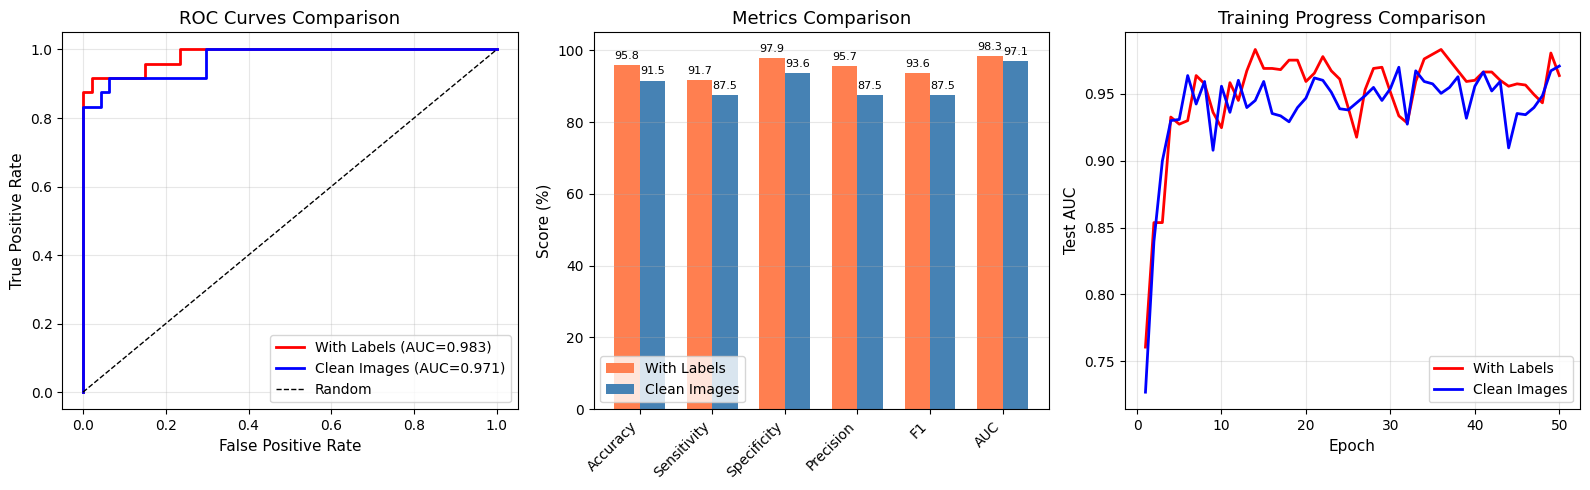

Comparison figure saved to: comparison_with_vs_clean.png


In [67]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

fpr1, tpr1, _ = roc_curve(test_labels, test_probs)
fpr2, tpr2, _ = roc_curve(test_labels_clean_eval, test_probs_clean)

axes[0].plot(fpr1, tpr1, 'r-', lw=2, label=f'With Labels (AUC={exp1_results["auc_roc"]:.3f})')
axes[0].plot(fpr2, tpr2, 'b-', lw=2, label=f'Clean Images (AUC={exp2_results["auc_roc"]:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate', fontsize=11)
axes[0].set_title('ROC Curves Comparison', fontsize=13)
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

metrics = ['Accuracy', 'Sensitivity', 'Specificity', 'Precision', 'F1', 'AUC']
exp1_vals = [exp1_results['accuracy'], exp1_results['sensitivity'], exp1_results['specificity'], 
             exp1_results['precision'], exp1_results['f1'], exp1_results['auc_roc']]
exp2_vals = [exp2_results['accuracy'], exp2_results['sensitivity'], exp2_results['specificity'],
             exp2_results['precision'], exp2_results['f1'], exp2_results['auc_roc']]

x = np.arange(len(metrics))
width = 0.35

bars1 = axes[1].bar(x - width/2, [v*100 for v in exp1_vals], width, label='With Labels', color='coral')
bars2 = axes[1].bar(x + width/2, [v*100 for v in exp2_vals], width, label='Clean Images', color='steelblue')

axes[1].set_ylabel('Score (%)', fontsize=11)
axes[1].set_title('Metrics Comparison', fontsize=13)
axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics, rotation=45, ha='right')
axes[1].legend()
axes[1].set_ylim([0, 105])
axes[1].grid(True, alpha=0.3, axis='y')

for bar in bars1:
    height = bar.get_height()
    axes[1].annotate(f'{height:.1f}', xy=(bar.get_x() + bar.get_width()/2, height),
                     xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8)
for bar in bars2:
    height = bar.get_height()
    axes[1].annotate(f'{height:.1f}', xy=(bar.get_x() + bar.get_width()/2, height),
                     xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8)

epochs_range = range(1, EPOCHS + 1)
axes[2].plot(epochs_range, history["test_auc"], 'r-', lw=2, label='With Labels')
axes[2].plot(epochs_range, history_clean["test_auc"], 'b-', lw=2, label='Clean Images')
axes[2].set_xlabel('Epoch', fontsize=11)
axes[2].set_ylabel('Test AUC', fontsize=11)
axes[2].set_title('Training Progress Comparison', fontsize=13)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('comparison_with_vs_clean.png', dpi=150)
plt.show()

print("Comparison figure saved to: comparison_with_vs_clean.png")

In [68]:
writer_clean.close()

print(f"\nSummary:")
print(f"  Experiment 1 (With Labels):  AUC = {exp1_results['auc_roc']*100:.2f}%")
print(f"  Experiment 2 (Clean Images): AUC = {exp2_results['auc_roc']*100:.2f}%")
print(f"  Difference: {(exp1_results['auc_roc'] - exp2_results['auc_roc'])*100:+.2f}%")
print(f"\nFiles saved:")
print(f"  - best_model.pth (trained on labeled images)")
print(f"  - best_model_clean.pth (trained on clean images)")
print(f"  - comparison_with_vs_clean.png")
print(f"  - TensorBoard logs in ./logs/")



Summary:
  Experiment 1 (With Labels):  AUC = 98.32%
  Experiment 2 (Clean Images): AUC = 97.07%
  Difference: +1.24%

Files saved:
  - best_model.pth (trained on labeled images)
  - best_model_clean.pth (trained on clean images)
  - comparison_with_vs_clean.png
  - TensorBoard logs in ./logs/


---

## Grad-CAM Analysis

Gradient-weighted Class Activation Mapping (Grad-CAM) visualizes which regions of the image the model focuses on when making predictions. This is **critical evidence** for the thesis:

- If the **labeled-image model** focuses on text/measurement regions → confirms data leakage
- If the **clean-image model** focuses on hip anatomy → confirms legitimate learning

We'll compare attention maps from both models on the same test images.

In [69]:
import torch.nn.functional as F
from PIL import Image
import matplotlib.cm as cm

class GradCAM:    
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)
    
    def _save_activation(self, module, input, output):
        self.activations = output.detach()
    
    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()
    
    def generate_cam(self, input_tensor, target_class=None):
        self.model.eval()
        
        output = self.model(input_tensor)
        
        if target_class is None:
            target_class = (torch.sigmoid(output) > 0.5).long().item()
        
        self.model.zero_grad()
        
        if target_class == 1:
            output.backward()
        else:
            (-output).backward()
        
        gradients = self.gradients  
        activations = self.activations 
        
        weights = torch.mean(gradients, dim=(2, 3), keepdim=True) 
        
        cam = torch.sum(weights * activations, dim=1, keepdim=True)  
        
        cam = F.relu(cam)
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        
        return cam.squeeze().cpu().numpy()


def overlay_cam_on_image(img_path, cam, alpha=0.5):
    # Load original image
    img = Image.open(img_path).convert('RGB')
    img = img.resize((224, 224))
    img_array = np.array(img) / 255.0
    
    # Resize CAM to match image size
    cam_resized = np.array(Image.fromarray((cam * 255).astype(np.uint8)).resize((224, 224))) / 255.0
    
    heatmap = cm.jet(cam_resized)[:, :, :3]
    
    overlaid = (1 - alpha) * img_array + alpha * heatmap
    overlaid = np.clip(overlaid, 0, 1)
    
    return img_array, cam_resized, overlaid


print("Grad-CAM class defined")

Grad-CAM class defined


In [70]:
model_labeled = resnet50(weights=None)
model_labeled.fc = torch.nn.Linear(model_labeled.fc.in_features, 1)
model_labeled.load_state_dict(torch.load("best_model.pth", map_location=device, weights_only=True))
model_labeled = model_labeled.to(device)
model_labeled.eval()

model_clean_loaded = resnet50(weights=None)
model_clean_loaded.fc = torch.nn.Linear(model_clean_loaded.fc.in_features, 1)
model_clean_loaded.load_state_dict(torch.load("best_model_clean.pth", map_location=device, weights_only=True))
model_clean_loaded = model_clean_loaded.to(device)
model_clean_loaded.eval()

gradcam_labeled = GradCAM(model_labeled, model_labeled.layer4[-1])
gradcam_clean = GradCAM(model_clean_loaded, model_clean_loaded.layer4[-1])

print("Both models loaded")
print("Grad-CAM initialized targeting ResNet50 layer4 (final conv block)")

Both models loaded
Grad-CAM initialized targeting ResNet50 layer4 (final conv block)


In [71]:
ddh_uncleaned = [Path(f) for f, l in zip(test_files, test_labels) if l == 1 and 'uncleaned' in f.lower()]
normal_uncleaned = [Path(f) for f, l in zip(test_files, test_labels) if l == 0 and 'uncleaned' in f.lower()]

print(f"Found {len(ddh_uncleaned)} DDH images with 'uncleaned' in name")
print(f"Found {len(normal_uncleaned)} Normal images with 'uncleaned' in name")

sample_images = list(ddh_uncleaned) + list(normal_uncleaned)
sample_labels = [1] * len(ddh_uncleaned) + [0] * len(normal_uncleaned)

print(f"\nUsing ALL {len(sample_images)} uncleaned images for Grad-CAM analysis")
print(f"  - DDH: {len(ddh_uncleaned)}")
print(f"  - Normal: {len(normal_uncleaned)}")

Found 9 DDH images with 'uncleaned' in name
Found 1 Normal images with 'uncleaned' in name

Using ALL 10 uncleaned images for Grad-CAM analysis
  - DDH: 9
  - Normal: 1


In [72]:
def preprocess_for_gradcam(img_path):
    img = Image.open(img_path).convert('L')  # Grayscale
    img = img.resize((224, 224))
    img_array = np.array(img, dtype=np.float32) / 255.0
    
    img_3ch = np.stack([img_array] * 3, axis=0)
    
    mean = np.array(IMAGENET_MEAN).reshape(3, 1, 1)
    std = np.array(IMAGENET_STD).reshape(3, 1, 1)
    img_normalized = (img_3ch - mean) / std
    
    tensor = torch.from_numpy(img_normalized).float().unsqueeze(0)
    return tensor.to(device)


gradcam_results = []

for img_path, true_label in zip(sample_images, sample_labels):
    print(f"Processing: {img_path.name}...")
    
    input_tensor = preprocess_for_gradcam(img_path)
    
    cam_labeled = gradcam_labeled.generate_cam(input_tensor.clone())
    cam_clean = gradcam_clean.generate_cam(input_tensor.clone())
    
    with torch.no_grad():
        pred_labeled = torch.sigmoid(model_labeled(input_tensor)).item()
        pred_clean = torch.sigmoid(model_clean_loaded(input_tensor)).item()
    
    gradcam_results.append({
        'path': img_path,
        'true_label': true_label,
        'cam_labeled': cam_labeled,
        'cam_clean': cam_clean,
        'pred_labeled': pred_labeled,
        'pred_clean': pred_clean
    })

print(f"\n✓ Generated Grad-CAM for {len(gradcam_results)} images")

Processing: uncleaned32.jpg...
Processing: uncleaned15.jpg...
Processing: uncleaned14.jpg...
Processing: uncleaned27.jpg...
Processing: uncleaned9.jpg...
Processing: uncleaned29.jpg...
Processing: uncleaned22.jpg...
Processing: uncleaned11.jpg...
Processing: uncleaned24.jpg...
Processing: uncleaned_normal.jpg...

✓ Generated Grad-CAM for 10 images


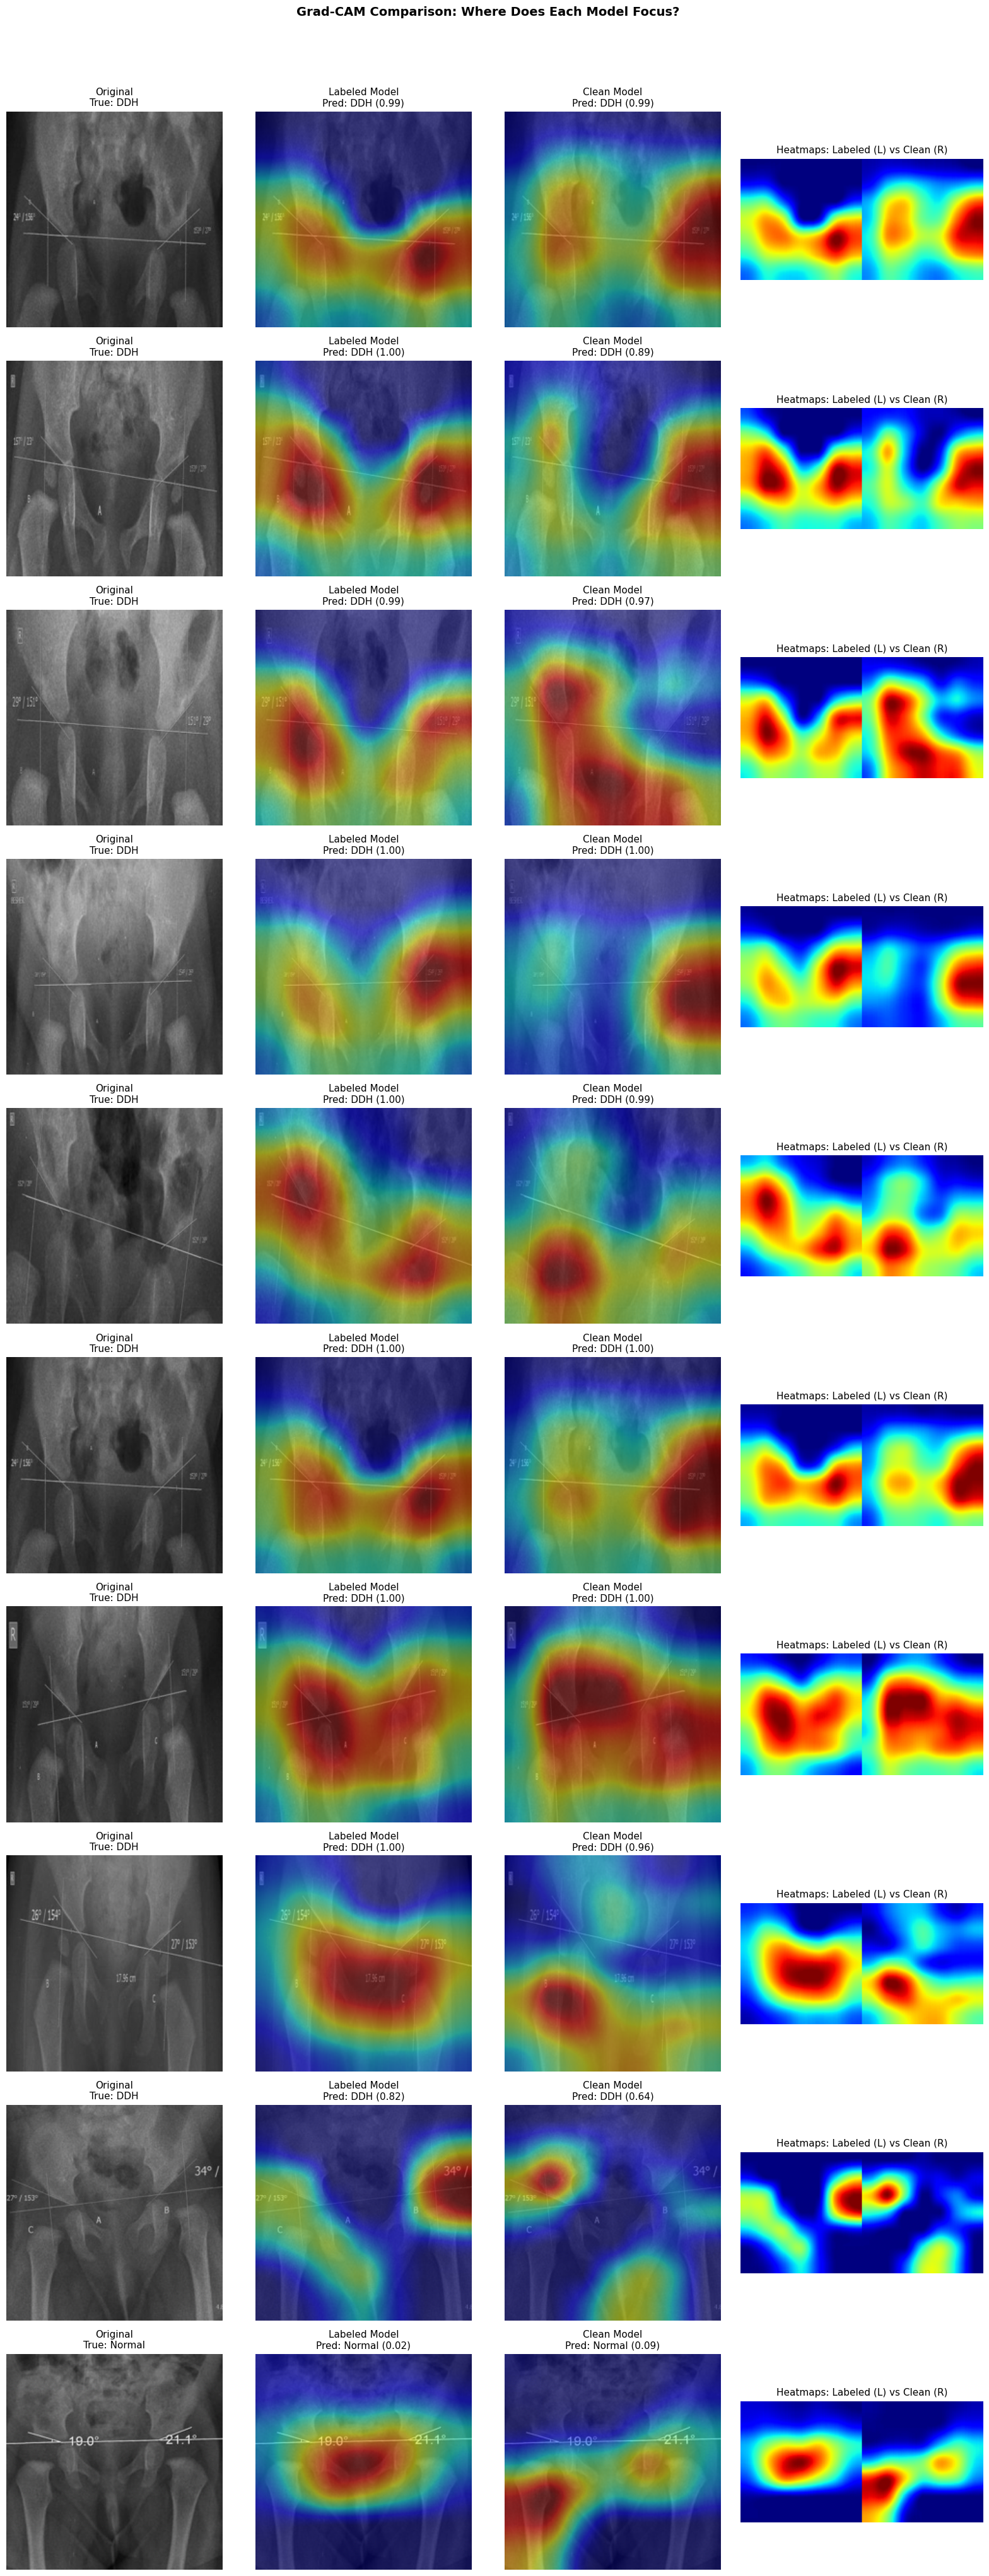


Grad-CAM visualization saved to: gradcam_comparison.png


In [73]:
fig, axes = plt.subplots(len(gradcam_results), 4, figsize=(16, 4 * len(gradcam_results)))

for i, result in enumerate(gradcam_results):
    img_path = result['path']
    true_label = result['true_label']
    cam_labeled = result['cam_labeled']
    cam_clean = result['cam_clean']
    pred_labeled = result['pred_labeled']
    pred_clean = result['pred_clean']
    
    orig_img, _, overlay_labeled = overlay_cam_on_image(img_path, cam_labeled, alpha=0.5)
    _, _, overlay_clean = overlay_cam_on_image(img_path, cam_clean, alpha=0.5)
    
    axes[i, 0].imshow(orig_img)
    axes[i, 0].set_title(f"Original\nTrue: {'DDH' if true_label == 1 else 'Normal'}", fontsize=11)
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(overlay_labeled)
    pred_class_l = 'DDH' if pred_labeled > 0.5 else 'Normal'
    axes[i, 1].set_title(f"Labeled Model\nPred: {pred_class_l} ({pred_labeled:.2f})", fontsize=11)
    axes[i, 1].axis('off')
    
    axes[i, 2].imshow(overlay_clean)
    pred_class_c = 'DDH' if pred_clean > 0.5 else 'Normal'
    axes[i, 2].set_title(f"Clean Model\nPred: {pred_class_c} ({pred_clean:.2f})", fontsize=11)
    axes[i, 2].axis('off')
    
    cam_labeled_resized = np.array(Image.fromarray((cam_labeled * 255).astype(np.uint8)).resize((112, 112))) / 255.0
    cam_clean_resized = np.array(Image.fromarray((cam_clean * 255).astype(np.uint8)).resize((112, 112))) / 255.0
    
    combined_cam = np.concatenate([
        cm.jet(cam_labeled_resized)[:, :, :3],
        cm.jet(cam_clean_resized)[:, :, :3]
    ], axis=1)
    axes[i, 3].imshow(combined_cam)
    axes[i, 3].set_title("Heatmaps: Labeled (L) vs Clean (R)", fontsize=11)
    axes[i, 3].axis('off')

plt.suptitle("Grad-CAM Comparison: Where Does Each Model Focus?", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('gradcam_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nGrad-CAM visualization saved to: gradcam_comparison.png")

In [74]:
def calculate_attention_centroid(cam, threshold=0.5):
    mask = cam > threshold
    if mask.sum() == 0:
        mask = cam > cam.mean()  
    
    y_indices, x_indices = np.where(mask)
    if len(y_indices) == 0:
        return 0.5, 0.5  
    
    weights = cam[mask]
    centroid_y = np.average(y_indices, weights=weights) / cam.shape[0]
    centroid_x = np.average(x_indices, weights=weights) / cam.shape[1]
    
    return centroid_x, centroid_y


print("Attention Centroid Analysis:")
print(f"{'Image':<20} {'Labeled (x,y)':<20} {'Clean (x,y)':<20}")

centroids_labeled = []
centroids_clean = []

for result in gradcam_results:
    cx_l, cy_l = calculate_attention_centroid(result['cam_labeled'])
    cx_c, cy_c = calculate_attention_centroid(result['cam_clean'])
    
    centroids_labeled.append((cx_l, cy_l))
    centroids_clean.append((cx_c, cy_c))
    
    print(f"{result['path'].name:<20} ({cx_l:.2f}, {cy_l:.2f})          ({cx_c:.2f}, {cy_c:.2f})")

def distance_from_center(centroids):
    return np.mean([np.sqrt((cx - 0.5)**2 + (cy - 0.5)**2) for cx, cy in centroids])

dist_labeled = distance_from_center(centroids_labeled)
dist_clean = distance_from_center(centroids_clean)

print(f"\nAverage distance from image center:")
print(f"  Labeled model: {dist_labeled:.3f}")
print(f"  Clean model:   {dist_clean:.3f}")

Attention Centroid Analysis:
Image                Labeled (x,y)        Clean (x,y)         
uncleaned32.jpg      (0.48, 0.59)          (0.53, 0.51)
uncleaned15.jpg      (0.42, 0.51)          (0.61, 0.55)
uncleaned14.jpg      (0.39, 0.59)          (0.36, 0.60)
uncleaned27.jpg      (0.50, 0.55)          (0.78, 0.57)
uncleaned9.jpg       (0.40, 0.51)          (0.39, 0.66)
uncleaned29.jpg      (0.43, 0.57)          (0.56, 0.56)
uncleaned22.jpg      (0.41, 0.47)          (0.46, 0.47)
uncleaned11.jpg      (0.49, 0.49)          (0.35, 0.70)
uncleaned24.jpg      (0.54, 0.39)          (0.31, 0.55)
uncleaned_normal.jpg (0.44, 0.42)          (0.24, 0.62)

Average distance from image center:
  Labeled model: 0.089
  Clean model:   0.167
